# STEP 6: Economic Impact & Investor Recommendations
### SpaceFund Realty (SFR) Aerospace Ratings Engine — Capstone Project

**Owner:** Karabelo Thonkha (R)  —  Sikiru Mustapha (C)

---
**Pipeline position:** `... → XGBoost & SHAP → Economic Impact & Investor Recommendations`
Reads `train_clean.csv`, `val_clean.csv`, `test_clean.csv` (Step 1). Produces `karabelo_economic_analysis.png` and `economic_findings_summary.json`.

## 6.1 — Mount Drive & Load Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import json
import warnings
warnings.filterwarnings("ignore")

PROJECT_FOLDER = "/content/drive/MyDrive/Gamma_Group_1"

# Set visual style, matching the "Deep Space" theme used across the rest of the project
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
NAVY, AMBER, ICE = "#0B1D3A", "#E8A33D", "#CADCFC"

def load_data():
    """Load the train, validation, and test clean datasets."""
    print("Loading cleaned datasets...")
    train_df = pd.read_csv(f"{PROJECT_FOLDER}/train_clean.csv")
    val_df = pd.read_csv(f"{PROJECT_FOLDER}/val_clean.csv")
    test_df = pd.read_csv(f"{PROJECT_FOLDER}/test_clean.csv")

    # Combine all three splits for a full-dataset economic view. Note: this is
    # SAFE here specifically because this notebook does purely descriptive /
    # explanatory analysis -- it does not train or evaluate a predictive model,
    # so there is no leakage risk in looking at the complete picture.
    full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
    print(f"Loaded {len(train_df)} train + {len(val_df)} val + {len(test_df)} test = {len(full_df)} total companies")
    return train_df, val_df, test_df, full_df

train_df, val_df, test_df, full_df = load_data()

Mounted at /content/drive
Loading cleaned datasets...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Gamma_Group_1/train_clean.csv'

## 6.2 — Economic Summary Statistics


In [ ]:
def economic_summary_statistics(df, name="Dataset"):
    """Compute economic summary metrics: funding, cost, price per kg, payload vs SFR rating."""
    print(f"\n--- Economic Summary Statistics ({name}) ---")
    econ_cols = ["SFR", "Payload (kg)", "Launch Cost ($M)", "Price ($/kg)", "Funding_num"]
    available_cols = [c for c in econ_cols if c in df.columns]
    summary = df[available_cols].describe().T[["mean", "std", "min", "50%", "max"]]
    summary.rename(columns={"50%": "median"}, inplace=True)
    print(summary.round(2))
    return summary

summary_stats = economic_summary_statistics(full_df, name="Full Combined Dataset (183 companies)")


--- Economic Summary Statistics (Full Combined Dataset (183 companies)) ---
                     mean       std   min  median       max
SFR                  3.73      2.53  0.00    3.00       9.0
Payload (kg)      2579.68   8834.39  0.00  186.00   63800.0
Launch Cost ($M)     4.84     19.13  0.00    0.00     170.0
Price ($/kg)      6587.26  12755.24  0.00    0.00  100000.0
Funding_num         87.22    636.63  0.05   13.84    8410.0


## 6.3 — Cost Efficiency & Pricing by Launch Class and Orbit Altitude


In [ ]:
def analyze_cost_efficiency(df):
    """Analyze cost efficiency and pricing models across launch classes and orbit altitudes (raw combination labels)."""
    print("\n--- Cost Efficiency & Pricing Analysis (raw combination labels) ---")

    if "Launch Class" in df.columns and "SFR" in df.columns:
        class_group = df.groupby("Launch Class").agg({
            "SFR": ["mean", "median", "count"],
            "Launch Cost ($M)": "mean",
            "Price ($/kg)": "mean",
            "Funding_num": "mean"
        }).round(2)
        print("\nMetrics by Launch Class (raw combination):")
        print(class_group)

    if "Orbit Altitude" in df.columns:
        orbit_group = df.groupby("Orbit Altitude").agg({
            "SFR": ["mean", "count"],
            "Launch Cost ($M)": "mean",
            "Price ($/kg)": "mean",
            "Payload (kg)": "mean"
        }).round(2)
        print("\nMetrics by Orbit Altitude (raw combination):")
        print(orbit_group)

analyze_cost_efficiency(full_df)


--- Cost Efficiency & Pricing Analysis (raw combination labels) ---

Metrics by Launch Class (raw combination):
                        SFR              Launch Cost ($M) Price ($/kg)  \
                       mean median count             mean         mean   
Launch Class                                                             
Heavy                  1.60    1.0     5             0.82       432.80   
Heavy, Super Heavy     9.00    9.0     1            90.00      1411.00   
Medium                 4.55    5.0    11            14.32      1525.55   
Medium, Heavy          6.00    6.5     4            74.25      3625.75   
Small                  3.59    3.0   129             1.89      8789.36   
Small, Heavy           8.00    8.0     1            10.00      8000.00   
Small, Medium          8.17    9.0     6            13.33      4066.67   
Tourism                4.00    4.5     8             0.38       504.00   
Tourism, Medium        5.00    5.0     1             0.00         0.00   

### 6.3b — Cleaner Single-Category Breakdown (Using Multi-Hot Columns)


In [ ]:
def single_category_breakdown(df):
    """Breaks down average SFR, cost, and price for each individual Launch Class
    and Orbit Altitude label, using the multi-hot flag columns from Step 1 --
    avoids the raw-combination-label ambiguity above."""
    rows = []
    for flag_col in ["LC_Heavy", "LC_Medium", "LC_Small", "LC_Tourism"]:
        if flag_col in df.columns:
            subset = df[df[flag_col] == 1]
            rows.append({
                "category": flag_col.replace("LC_", "Launch Class: "),
                "n_companies": len(subset),
                "avg_SFR": subset["SFR"].mean(),
                "avg_launch_cost_M": subset["Launch Cost ($M)"].mean(),
                "avg_price_per_kg": subset["Price ($/kg)"].mean(),
            })
    for flag_col in ["OA_LEO", "OA_Suborbital", "OA_Lunar"]:
        if flag_col in df.columns:
            subset = df[df[flag_col] == 1]
            rows.append({
                "category": flag_col.replace("OA_", "Orbit: "),
                "n_companies": len(subset),
                "avg_SFR": subset["SFR"].mean(),
                "avg_launch_cost_M": subset["Launch Cost ($M)"].mean(),
                "avg_price_per_kg": subset["Price ($/kg)"].mean(),
            })
    return pd.DataFrame(rows).round(2)

category_breakdown = single_category_breakdown(full_df)
print(category_breakdown.to_string(index=False))

             category  n_companies  avg_SFR  avg_launch_cost_M  avg_price_per_kg
  Launch Class: Heavy           12     4.83              33.43           2173.17
 Launch Class: Medium           22     5.82              24.30           2531.09
  Launch Class: Small          137     3.86               2.44           8512.61
Launch Class: Tourism           10     4.60               0.30            403.20
           Orbit: LEO          145     3.52               6.07           8043.60
    Orbit: Suborbital           33     4.91               0.16           1186.24
         Orbit: Lunar            1     1.00               0.05              0.00


## 6.4 — Econometric OLS Regression (Plain-Language Investor Coefficients)


In [ ]:
def run_econometric_regression(train_df):
    """Run an OLS econometric regression, in raw units, to assess financial
    drivers of SFR ratings in directly interpretable terms."""
    print("\n--- Econometric OLS Regression on SFR Ratings (raw units) ---")

    features = ["Payload (kg)", "Launch Cost ($M)", "Funding_num"]
    reg_df = train_df[["SFR"] + features].dropna()
    print(f"Regression sample size: {len(reg_df)} companies (rows with missing values excluded)")

    X = reg_df[features]
    y = reg_df["SFR"]

    X_sm = sm.add_constant(X)
    model = sm.OLS(y, X_sm).fit()
    print(model.summary())

    return model, reg_df

econ_model, reg_df = run_econometric_regression(train_df)


--- Econometric OLS Regression on SFR Ratings (raw units) ---
Regression sample size: 155 companies (rows with missing values excluded)
                            OLS Regression Results                            
Dep. Variable:                    SFR   R-squared:                       0.202
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     12.71
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           1.89e-07
Time:                        06:40:12   Log-Likelihood:                -344.28
No. Observations:                 155   AIC:                             696.6
Df Residuals:                     151   BIC:                             708.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025 

In [ ]:
# Translate the raw coefficients into plain-language investor statements
print("=== Plain-Language Interpretation ===\n")
for feature in ["Payload (kg)", "Launch Cost ($M)", "Funding_num"]:
    coef = econ_model.params[feature]
    pval = econ_model.pvalues[feature]
    significance = "statistically significant" if pval < 0.05 else "NOT statistically significant"
    direction = "increase" if coef > 0 else "decrease"
    unit = {"Payload (kg)": "1,000 kg of payload capacity", "Launch Cost ($M)": "$1M in launch cost", "Funding_num": "$1M in funding"}[feature]
    scale = 1000 if feature == "Payload (kg)" else 1
    print(f"- Each additional {unit} is associated with a {abs(coef * scale):.4f}-point {direction} "
          f"in predicted SFR rating (p={pval:.3f}, {significance}).")

print(f"\nModel R\u00b2: {econ_model.rsquared:.3f} -- explains {econ_model.rsquared*100:.1f}% of rating variation using only 3 raw financial/technical variables.")

=== Plain-Language Interpretation ===

- Each additional 1,000 kg of payload capacity is associated with a 0.0364-point decrease in predicted SFR rating (p=0.134, NOT statistically significant).
- Each additional $1M in launch cost is associated with a 0.0510-point increase in predicted SFR rating (p=0.000, statistically significant).
- Each additional $1M in funding is associated with a 0.0061-point increase in predicted SFR rating (p=0.000, statistically significant).

Model R²: 0.202 -- explains 20.2% of rating variation using only 3 raw financial/technical variables.


## 6.5 — Economic Visualization Dashboard



Generating economic visualization plots...
Saved economic analysis plots to '/content/drive/MyDrive/Gamma_Group_1/karabelo_economic_analysis.png'


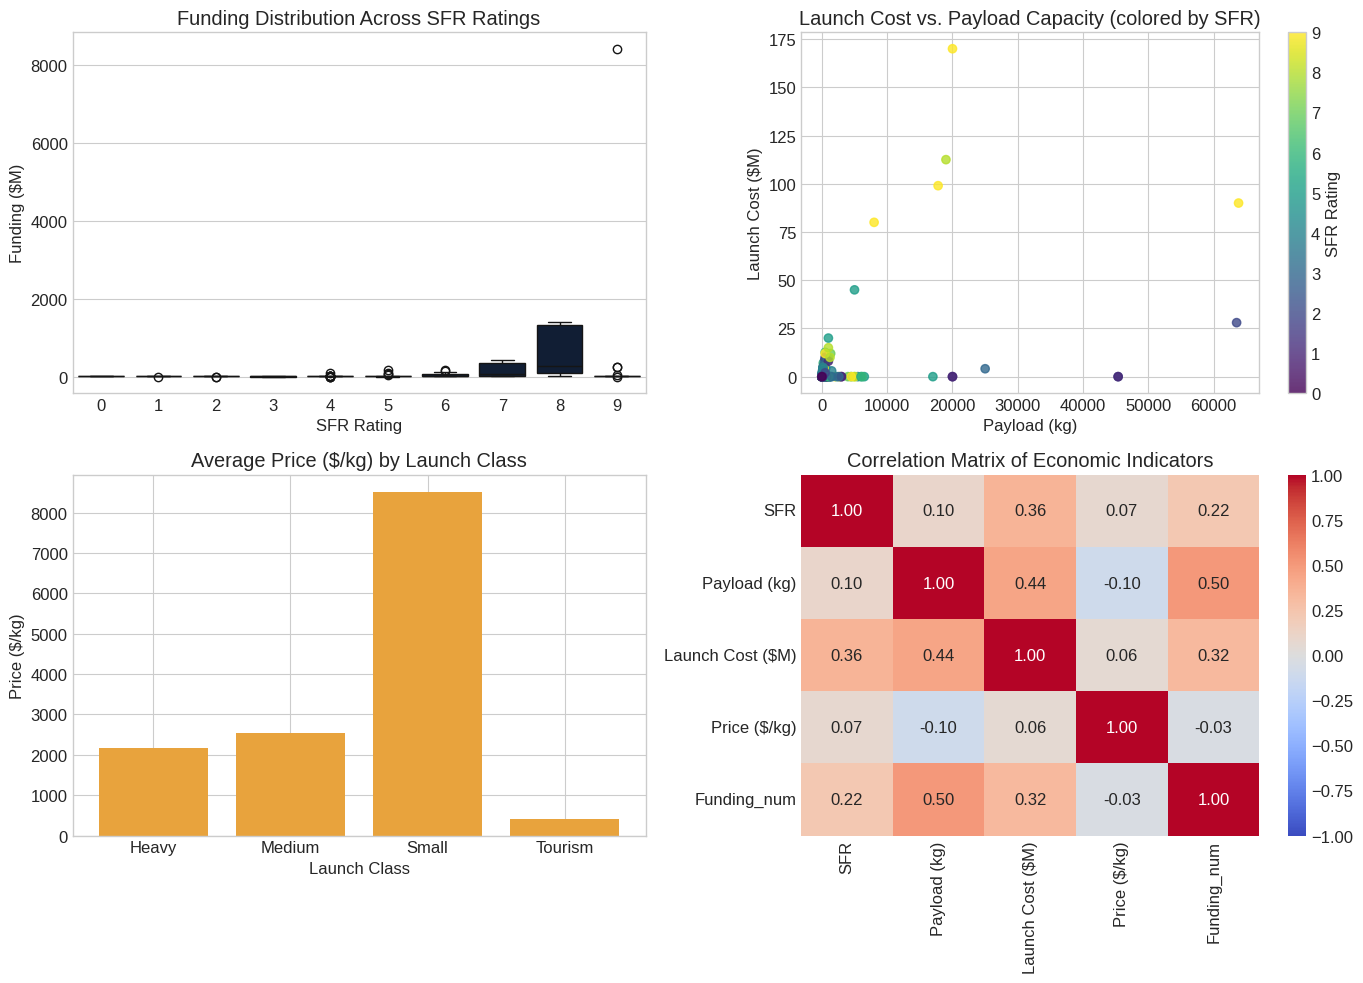

In [ ]:
def plot_economic_visualizations(df, save_path):
    """Generate and save key financial plots for economic evaluation."""
    print("\nGenerating economic visualization plots...")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Funding vs SFR Rating
    sns.boxplot(data=df, x="SFR", y="Funding_num", ax=axes[0, 0], color=NAVY)
    axes[0, 0].set_title("Funding Distribution Across SFR Ratings")
    axes[0, 0].set_xlabel("SFR Rating")
    axes[0, 0].set_ylabel("Funding ($M)")

    # 2. Launch Cost vs Payload, colored by SFR
    scatter = axes[0, 1].scatter(df["Payload (kg)"], df["Launch Cost ($M)"], c=df["SFR"], cmap="viridis", alpha=0.8)
    axes[0, 1].set_title("Launch Cost vs. Payload Capacity (colored by SFR)")
    axes[0, 1].set_xlabel("Payload (kg)")
    axes[0, 1].set_ylabel("Launch Cost ($M)")
    plt.colorbar(scatter, ax=axes[0, 1], label="SFR Rating")

    # 3. Price per kg by individual Launch Class (using the cleaner single-category breakdown)
    lc_data = category_breakdown[category_breakdown["category"].str.startswith("Launch Class")]
    axes[1, 0].bar(lc_data["category"].str.replace("Launch Class: ", ""), lc_data["avg_price_per_kg"], color=AMBER)
    axes[1, 0].set_title("Average Price ($/kg) by Launch Class")
    axes[1, 0].set_xlabel("Launch Class")
    axes[1, 0].set_ylabel("Price ($/kg)")

    # 4. Correlation Heatmap of Economic Features
    econ_cols = ["SFR", "Payload (kg)", "Launch Cost ($M)", "Price ($/kg)", "Funding_num"]
    corr = df[[c for c in econ_cols if c in df.columns]].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 1], vmin=-1, vmax=1)
    axes[1, 1].set_title("Correlation Matrix of Economic Indicators")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    print(f"Saved economic analysis plots to \'{save_path}\'")
    plt.show()

plot_economic_visualizations(full_df, f"{PROJECT_FOLDER}/karabelo_economic_analysis.png")

## 6.6 — Save Findings to Drive


In [ ]:
findings_summary = {
    "sample_size": {
        "train": len(train_df), "val": len(val_df), "test": len(test_df), "total": len(full_df),
    },
    "econometric_regression": {
        "r_squared": float(econ_model.rsquared),
        "coefficients": {f: float(econ_model.params[f]) for f in ["Payload (kg)", "Launch Cost ($M)", "Funding_num"]},
        "p_values": {f: float(econ_model.pvalues[f]) for f in ["Payload (kg)", "Launch Cost ($M)", "Funding_num"]},
    },
    "category_breakdown": category_breakdown.to_dict(orient="records"),
}

with open(f"{PROJECT_FOLDER}/economic_findings_summary.json", "w") as f:
    json.dump(findings_summary, f, indent=2)

print(f"Saved to Google Drive folder: {PROJECT_FOLDER}")
print("  - karabelo_economic_analysis.png")
print("  - economic_findings_summary.json")
print("\nStep 6 complete. Economic evaluation workflow finished successfully.")

Saved to Google Drive folder: /content/drive/MyDrive/Gamma_Group_1
  - karabelo_economic_analysis.png
  - economic_findings_summary.json

Step 6 complete. Economic evaluation workflow finished successfully.
